In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc 
import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction, plot_bio_vs_batch_correction_markers

/NOBACKUP/lizottem/fosta/.condaenv/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [6]:
results_path = "/NOBACKUP/lizottem/fosta/results/" 
exp = "simulated_paired_batches" 
timestamp = "2026-05-01_01-01-54"
result_name="simulated_batches"
results_path = f"{results_path}/{exp}/{timestamp}"


In [ ]:

# load results
results_df = pd.read_csv(f"{results_path}/{result_name}_results.csv")

results_df.columns = results_df.columns.str.replace('_', ' ')

# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['model', 'dataset', 'seed'])
# results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')


# take the abs for silhouette domain because it should be low, doesnt matter the sign
results_df['Silhouette domain'] = results_df['Silhouette domain'].abs()

results_df

,seed,n components,noise,dropout,model,FOSCTTM,Silhouette domain,Accuracy missing,Accuracy visible,Alignment score,time,memory
0,11784,2,0.5,0.5,Harmony,0.000000,0.001339,1.000000,NaN,1.000861,0.977178,783.263062
1,11784,2,0.5,0.5,KEMAlin,0.000000,0.001339,1.000000,NaN,1.001339,1.462774,9.778748
2,11784,2,0.5,0.5,KEMArbf,0.051349,0.001180,0.949130,NaN,0.947696,1.546292,9.776902
3,11784,2,0.5,0.5,LIGER,0.001708,0.001297,0.966533,NaN,0.991585,17.907778,2106.712427
4,11784,2,0.5,0.5,New FoSTA gap t=2,0.048463,0.001155,0.991968,NaN,0.916236,34.574271,335.596958
...,...,...,...,...,...,...,...,...,...,...,...,...
638,11784,2,0.4,0.4,scVI,0.000000,0.001339,1.000000,NaN,1.000000,634.993006,913.431172
639,11784,2,0.4,0.4,scANVI,0.000000,0.001339,1.000000,NaN,1.000000,733.366114,913.761798
640,11784,2,0.4,0.4,Pamona,0.000306,0.001318,0.993307,NaN,1.000191,577.991007,2491.510237
641,11784,2,0.4,0.4,KEMArbf,0.051349,0.001180,0.953146,NaN,0.948652,6.833259,9.776354


average over all datasets

In [14]:
summary_df = results_df.groupby(['model'])[num_cols].mean()
summary_df_std = results_df.groupby(['model'])[num_cols].std()
summary_df

,Accuracy missing,Accuracy visible,Alignment score,FOSCTTM,Silhouette domain,dropout,memory,n components,noise,time
model,,,,,,,,,,
Harmony,1.000000,NaN,1.001109,0.000000,0.001339,0.470270,647.875955,2.0,0.248649,1.093811
ICML FoSTA t=2,0.981563,NaN,0.807768,0.047503,0.001215,0.454545,1783.217387,2.0,0.268182,162.893869
ICML FoSTA t=auto,0.977547,NaN,0.895096,0.044324,0.001259,0.454545,1776.829349,2.0,0.268182,201.274264
KEMAlin,1.000000,NaN,1.000979,0.000000,0.001339,0.470270,9.778850,2.0,0.248649,1.951167
KEMArbf,0.949057,NaN,0.943232,0.054395,0.001172,0.470270,9.989111,2.0,0.248649,2.122060
LIGER,0.964977,NaN,0.993183,0.001667,0.001297,0.470270,1802.525482,2.0,0.248649,20.998242
MALI,0.903797,NaN,0.949112,0.118111,0.001281,0.454545,2824.958163,2.0,0.268182,86.354002
New FoSTA gap t=2,0.989833,NaN,0.923413,0.045415,0.001171,0.470270,333.525600,2.0,0.248649,74.417878
New FoSTA gap t=auto,0.990991,NaN,0.937922,0.063432,0.001306,0.470270,423.268269,2.0,0.248649,108.807386


In [4]:
summary_df_std

Accuracy missing  Accuracy visible  \
split                  model                                         
add noise features     FoSTA            0.157990          0.117993   
                       KEMAlin          0.184160          0.179325   
                       KEMArbf          0.199146          0.207698   
                       MALI             0.162181          0.137328   
                       Pamona           0.230366          0.197139   
                       RFMALI           0.162692          0.128904   
alternating importance FoSTA            0.150936          0.110122   
                       KEMAlin          0.220760          0.208381   
                       KEMArbf          0.192276          0.172823   
                       MALI             0.193415          0.175710   
                       Pamona           0.206919          0.189428   
                       RFMALI           0.154748          0.116992   
distort                FoSTA            0.132439          0.114411   
                       KEMAlin          0.197125          0.201103   
                       KEMArbf          0.195084          0.195045   
                       MALI             0.170438          0.167284   
                       Pamona           0.190350          0.188447   
                       RFMALI           0.131495          0.120711   
importance             FoSTA            0.129595          0.112782   
                       KEMAlin          0.191384          0.178174   
                       KEMArbf          0.160274          0.172100   
                       MALI             0.171698          0.192721   
                       Pamona           0.218649          0.255666   
                       RFMALI           0.133774          0.115305   
random                 FoSTA            0.131633          0.106163   
                       KEMAlin          0.185118          0.164520   
                       KEMArbf          0.187080          0.165849   
                       MALI             0.200643          0.195427   
                       Pamona           0.186863          0.168064   
                       RFMALI           0.139199          0.101631   
rotate                 FoSTA            0.134009          0.078769   
                       KEMAlin          0.217659          0.190920   
                       KEMArbf          0.199963          0.204937   
                       MALI             0.215520          0.216286   
                       Pamona           0.190661          0.187041   
                       RFMALI           0.129108          0.081145   

                                Alignment score   FOSCTTM  Silhouette domain  
split                  model                                                  
add noise features     FoSTA           0.154487  0.101696           0.036478  
                       KEMAlin         0.001768  0.092205           0.096258  
                       KEMArbf         0.010995  0.074283           0.143422  
                       MALI            0.056247  0.084765           0.004195  
                       Pamona          0.199242  0.081522           0.012623  
                       RFMALI          0.170303  0.108387           0.037371  
alternating importance FoSTA           0.210347  0.124928           0.009755  
                       KEMAlin         0.046141  0.062147           0.119301  
                       KEMArbf         0.039374  0.050746           0.082736  
                       MALI            0.112674  0.143337           0.002653  
                       Pamona          0.295488  0.177159           0.010047  
                       RFMALI          0.189593  0.127378           0.001498  
distort                FoSTA           0.210984  0.072982           0.018987  
                       KEMAlin         0.045769  0.080185           0.125347  
                       KEMArbf         0.035124  0.059248           0.107702  
                       MALI 

# print it to a table

subset to the methods/metrics we want

In [5]:
# clean summary_df 

def clean_summary_df(df):
    # remove "RFMALI" 
    df = df.loc[df.index.get_level_values('model') != 'RFMALI']

    cols_to_keep = ["Accuracy missing", "Alignment score", "FOSCTTM"]
    # rename Accuracy missing to Accuracy
    df = df[cols_to_keep]
    df = df.rename(columns={"Accuracy missing": "Accuracy"})
    return df

summary_df = clean_summary_df(summary_df)
summary_df_std = clean_summary_df(summary_df_std)

In [6]:
# Function to format the top 3 values: bold, underline, italic (adjusted for lower is better columns)
def format_top_3(df):
    formatted_df = df.copy()
    
    # List of columns where lower values are better
    lower_is_better_columns = ['FOSCTTM', 'Silhouette domain']
    
    # Group by 'split' to format the top 3 values in each split
    for split, group in df.groupby('split'):
        for column in group.columns:  # Start from the first numerical column
            if column in lower_is_better_columns:
                # Find the smallest 3 values (lower is better)
                top_3 = group[column].nsmallest(3).values
            else:
                # Find the largest 3 values (higher is better)
                top_3 = group[column].nlargest(3).values
            
            if len(top_3) >= 3:
                # Apply formatting: bold for best, underline for second, italic for third
                formatted_df.loc[group.index, column] = group[column].apply(
                    lambda x: f"\\textbf{{{x:.3f}}}" if x == top_3[0] else 
                              (f"\\underline{{{x:.3f}}}" if x == top_3[1] else 
                               (f"\\textit{{{x:.3f}}}" if x == top_3[2] else f"{x:.3f}"))
                )
    
    return formatted_df

In [11]:
summary_df_fmt = format_top_3(summary_df)


/tmp/ipykernel_3760867/3071777113.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['\\textbf{0.766}' '0.595' '0.513' '\\underline{0.713}' '\\textit{0.639}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[group.index, column] = group[column].apply(
/tmp/ipykernel_3760867/3071777113.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['\\textit{0.388}' '0.001' '0.018' '\\textbf{0.933}' '\\underline{0.718}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[group.index, column] = group[column].apply(
/tmp/ipykernel_3760867/3071777113.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['\\textbf{0.223}' '0.443' '0.444'

In [ ]:
# add std

# for col in summary_df.columns:
#     summary_df_fmt[col] = (
#         summary_df[col].round(3).astype(str)
#         + r" {\small $\pm$ "
#         + summary_df_std[col].round(3).astype(str)
#         + "}"
#     )

In [12]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(summary_df_fmt.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{lllll}
\toprule
 &  & Accuracy & Alignment score & FOSCTTM \\
split & model &  &  &  \\
\midrule
\multirow[t]{5}{*}{add noise features} & FoSTA & \textbf{0.766} & \textit{0.388} & \textbf{0.223} \\
 & KEMAlin & 0.595 & 0.001 & 0.443 \\
 & KEMArbf & 0.513 & 0.018 & 0.444 \\
 & MALI & \underline{0.713} & \textbf{0.933} & \underline{0.340} \\
 & Pamona & \textit{0.639} & \underline{0.718} & \textit{0.430} \\
\cline{1-5}
\multirow[t]{5}{*}{alternating importance} & FoSTA & \textbf{0.772} & \underline{0.720} & \textbf{0.313} \\
 & KEMAlin & 0.481 & 0.035 & 0.461 \\
 & KEMArbf & 0.508 & 0.030 & 0.462 \\
 & MALI & \underline{0.637} & \textbf{0.982} & \underline{0.375} \\
 & Pamona & \textit{0.634} & \textit{0.490} & \textit{0.394} \\
\cline{1-5}
\multirow[t]{5}{*}{distort} & FoSTA & \textbf{0.782} & \textit{0.757} & \textbf{0.216} \\
 & KEMAlin & 0.588 & 0.021 & 0.444 \\
 & KEMArbf & 0.541 & 0.030 & 0.453 \\
 & MALI & \underline{0.726} & \textbf{0.980} & \textit{0.256} \\
 & P

# bar plots

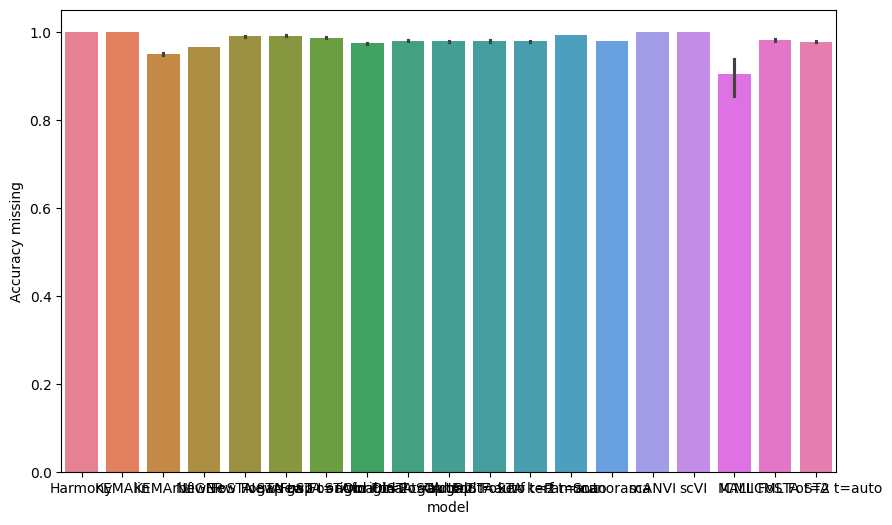

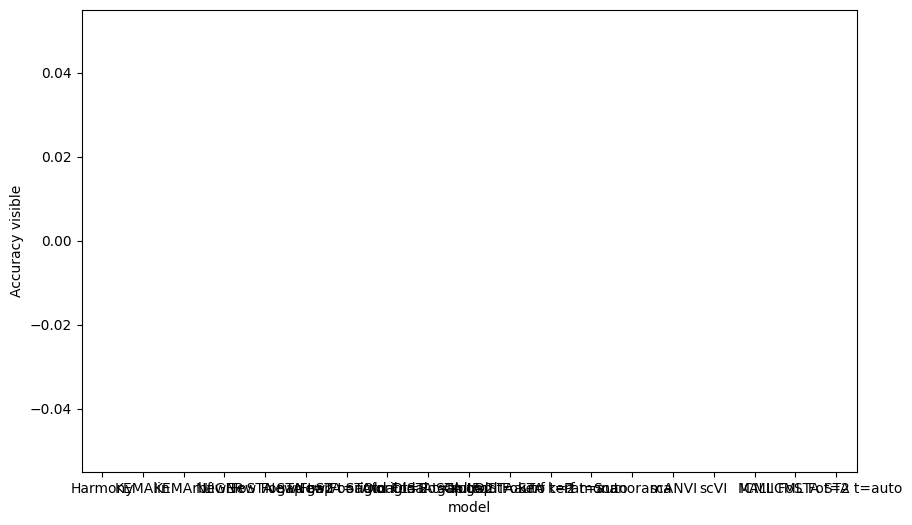

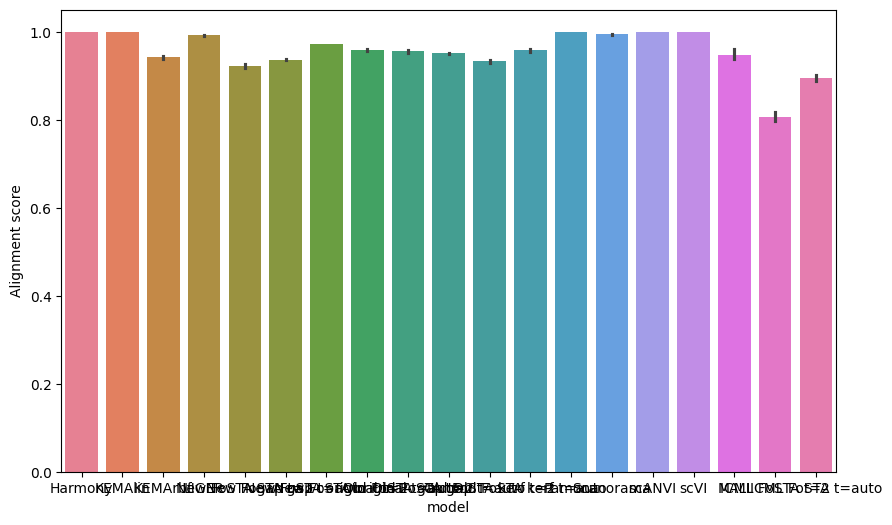

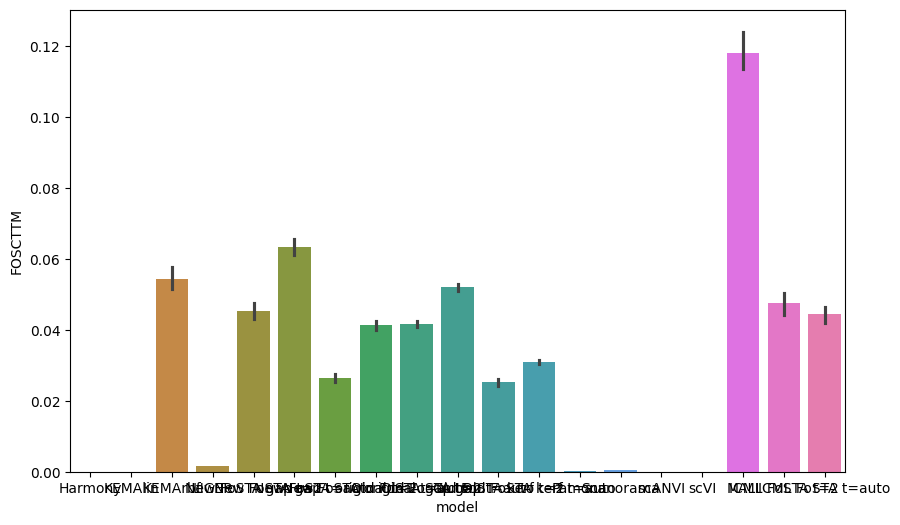

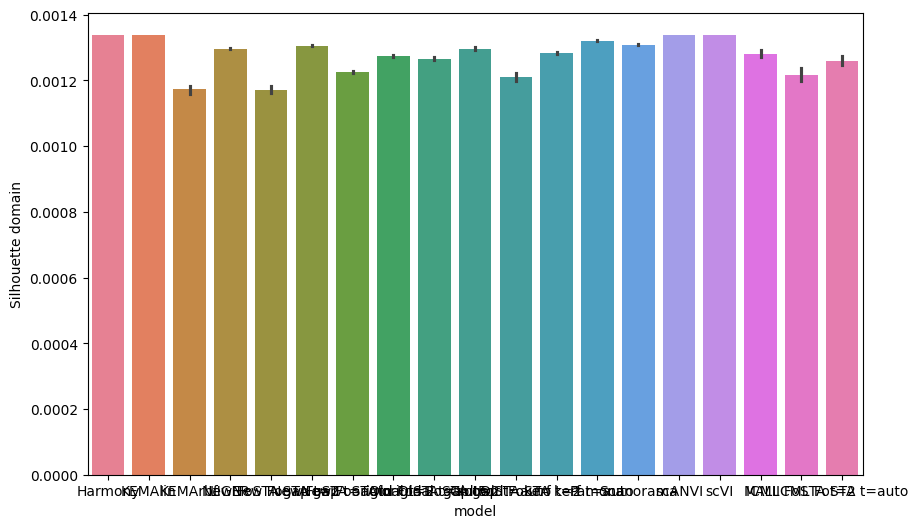

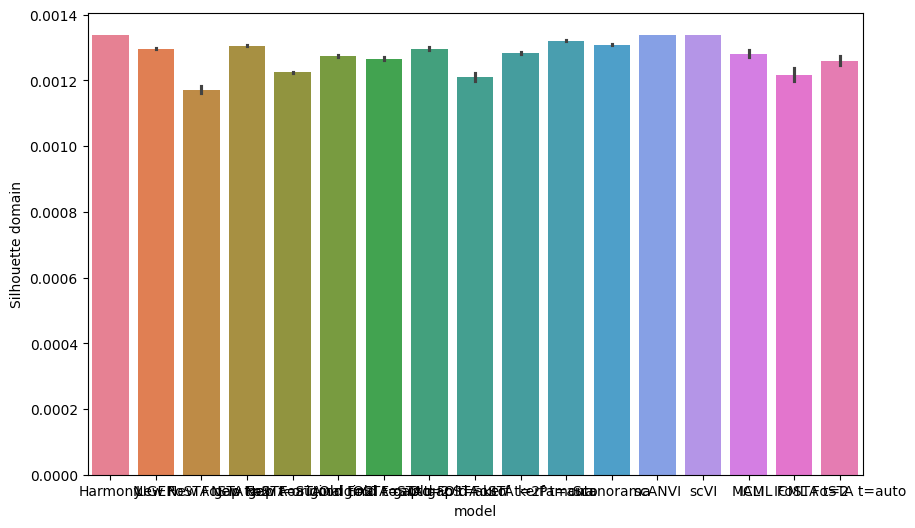

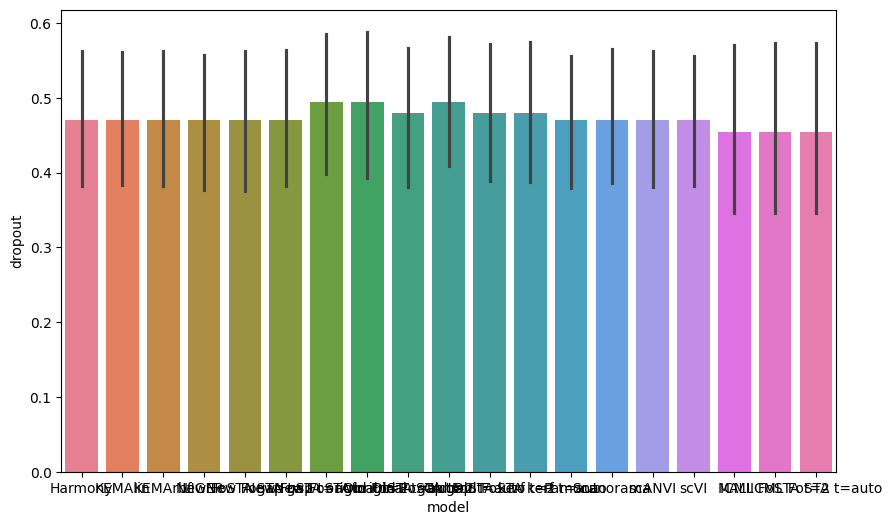

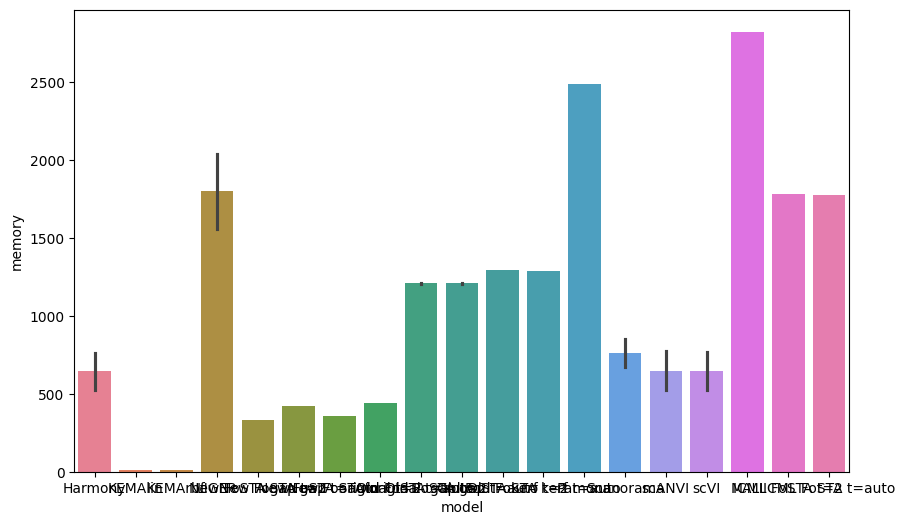

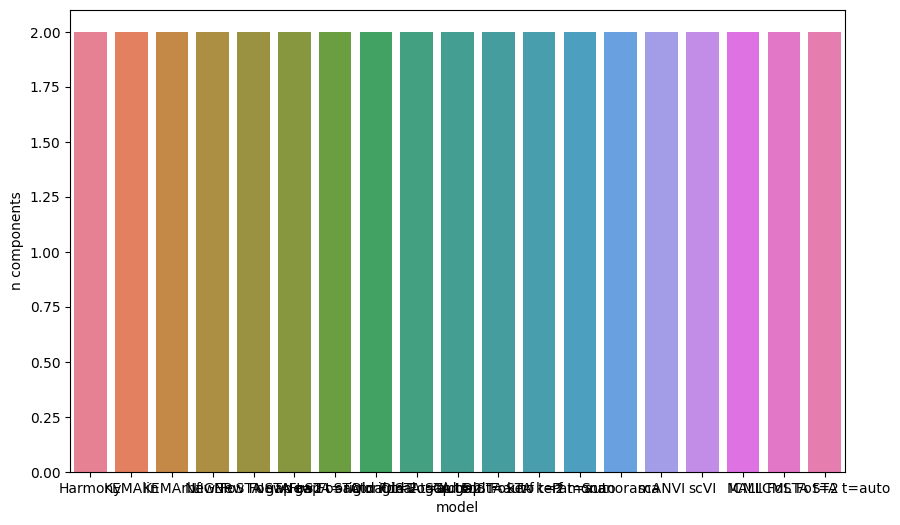

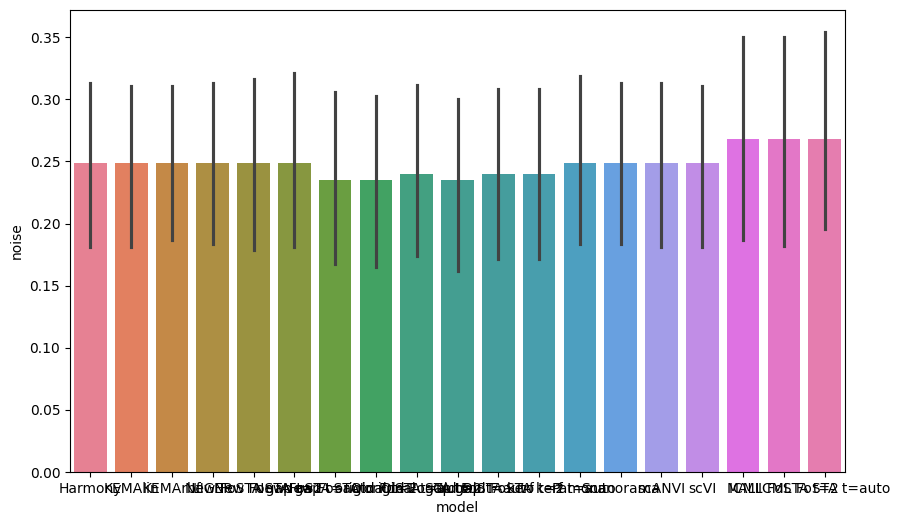

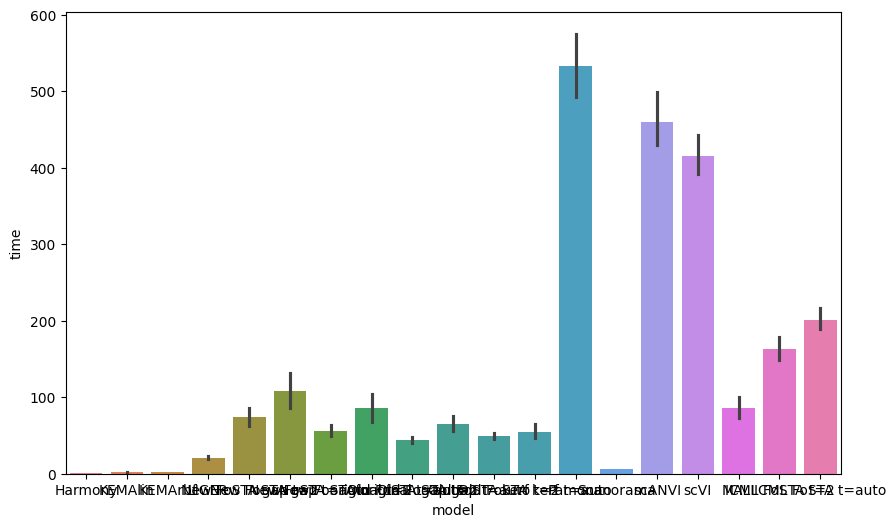

In [16]:
for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.barplot(data=results_df, x='model', y=col, hue='model')
    
    if col == "Silhouette domain":
        plt.figure(figsize=(10,6))
        sns.barplot(data=results_df[(results_df['model'] != "KEMArbf") & (results_df['model'] != "KEMAlin")], x='model', y=col, hue='model')
        plt.show()

# grouped by split

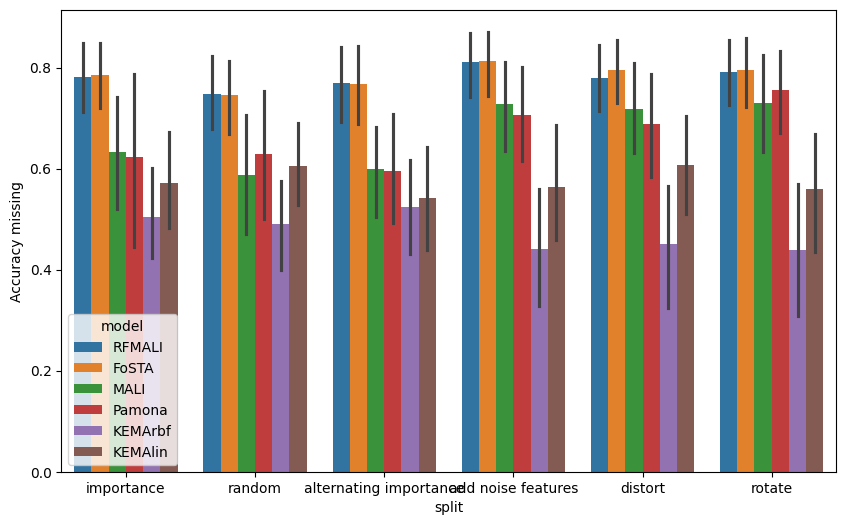

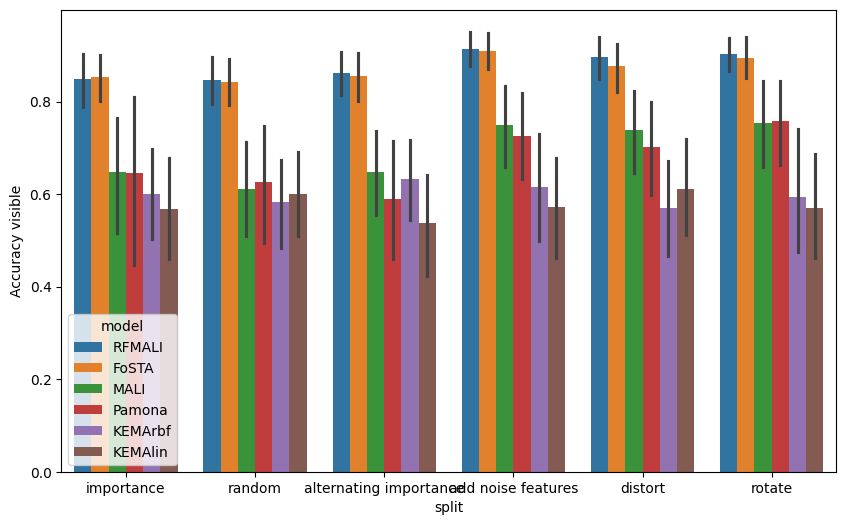

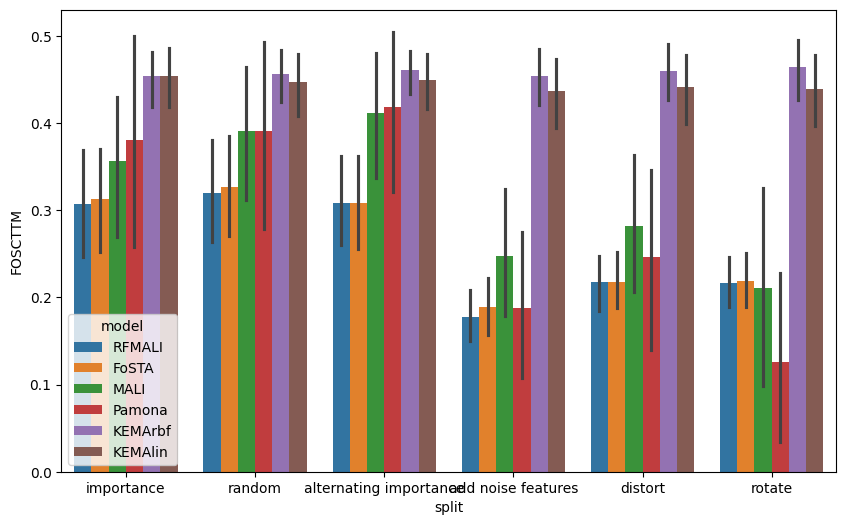

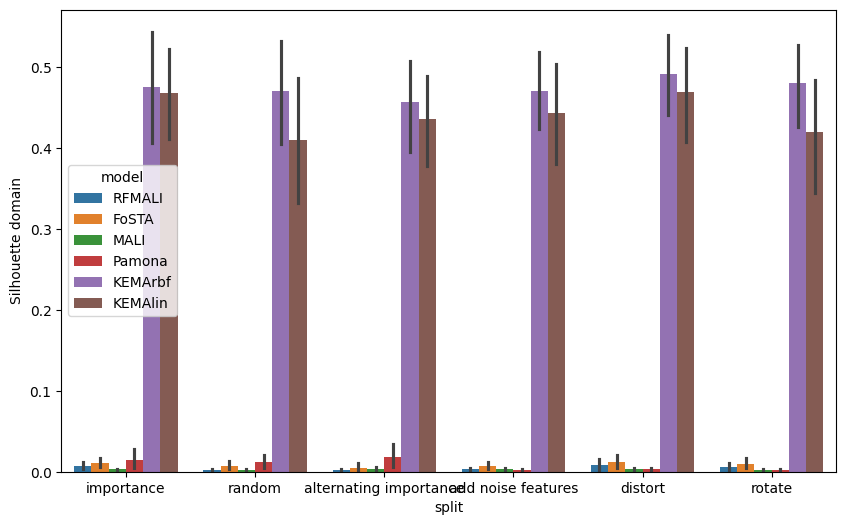

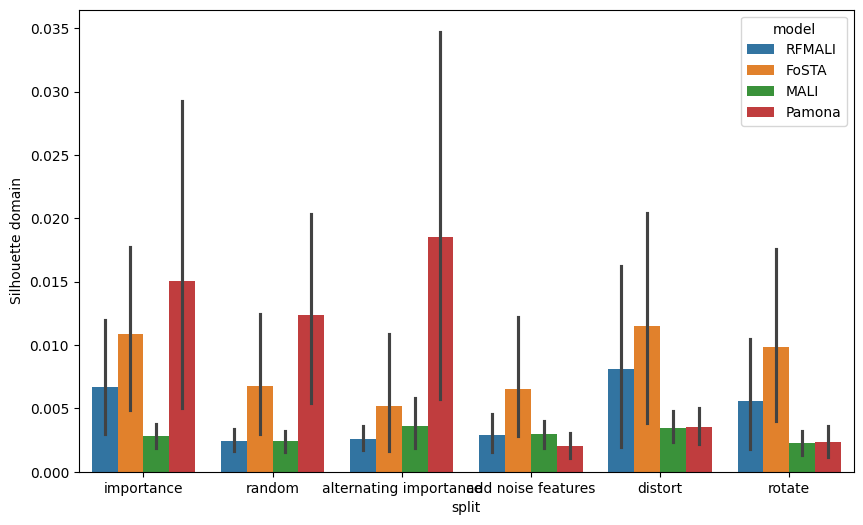

In [ ]:
for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.barplot(data=results_df, x='split', y=col, hue='model')
    
    if col == "Silhouette domain":
        plt.figure(figsize=(10,6))
        sns.barplot(data=results_df[(results_df['model'] != "KEMArbf") & (results_df['model'] != "KEMAlin")], x='split', y=col, hue='model')
        plt.show()

# checking the failed runs

In [ ]:
nas = results_df[results_df['Silhouette domain'].isna()][['split', 'dataset', 'model']]
nas

,split,dataset,model
2,importance,balance_scale,MALI
3,importance,balance_scale,Pamona
8,random,breast_cancer,MALI
9,random,breast_cancer,Pamona
14,importance,crx,MALI
15,importance,crx,Pamona
20,alternating importance,breast_cancer,MALI
21,alternating importance,breast_cancer,Pamona
27,alternating importance,balance_scale,Pamona
33,random,balance_scale,Pamona


In [ ]:
print(nas['split'].value_counts())
print(nas['dataset'].value_counts())
print(nas['model'].value_counts())

split
random                    47
importance                45
alternating importance    45
add noise features        43
Name: count, dtype: int64
dataset
flare1           16
balance_scale    15
breast_cancer    14
tic-tac-toe      14
crx              13
hepatitis        12
parkinsons       12
seeds            12
glass            12
iris             12
ionosphere       12
heart_disease    12
heart_failure    12
diabetes         12
Name: count, dtype: int64
model
RFMALI    56
FoSTA     56
MALI      56
Pamona    12
Name: count, dtype: int64


In [ ]:
datasets_path = "/home/mila/m/myriam.lizotte/scratch/rf-autoencoders/data"
data_name = "breast_cancer"
df = pd.read_csv(f"{datasets_path}/{data_name}.csv")

In [ ]:
import sys, pathlib
sys.path.insert(0, str(next(p for p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents) if (p/"src").is_dir())))
from utils.utils import dataprep
df, labels = dataprep(df) 

In [ ]:
df

,thickness,size_uniformity,shape_uniformity,adhesion,cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitosis
0,0.444444,0.000000,0.000000,0.000000,0.111111,0.000000,0.222222,0.000000,0.000
1,0.444444,0.333333,0.333333,0.444444,0.666667,1.000000,0.222222,0.111111,0.000
2,0.222222,0.000000,0.000000,0.000000,0.111111,0.111111,0.222222,0.000000,0.000
3,0.555556,0.777778,0.777778,0.000000,0.222222,0.333333,0.222222,0.666667,0.000
4,0.333333,0.000000,0.000000,0.222222,0.111111,0.000000,0.222222,0.000000,0.000
...,...,...,...,...,...,...,...,...,...
694,0.222222,0.000000,0.000000,0.000000,0.222222,0.111111,0.000000,0.000000,0.000
695,0.111111,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.000
696,0.444444,1.000000,1.000000,0.222222,0.666667,0.222222,0.777778,1.000000,0.125
697,0.333333,0.777778,0.555556,0.333333,0.222222,0.333333,1.000000,0.555556,0.000


In [ ]:
df.isna().sum()

thickness           0
size_uniformity     0
shape_uniformity    0
adhesion            0
cell_size           0
bare_nuclei         0
bland_chromatin     0
normal_nucleoli     0
mitosis             0
dtype: int64